# Antimicrobial Resistance (AMR) Prediction Pipeline

## Overview
This notebook builds a machine learning pipeline to predict Antimicrobial Resistance (AMR) phenotypes based on genome data, antibiotic types, and measurement details. 

## Key Steps:
1. **Data Loading & Cleaning**: Handling missing values and filtering valid phenotypes.
2. **Exploratory Data Analysis (EDA)**: Understanding distributions, class imbalances, and resistance rates by drug class.
3. **Statistical Analysis**: Validating the significance of features (`Evidence`, `has_measurement`, `Measurement Value`) against the target.
4. **Feature Engineering & Preprocessing**: Target encoding high-cardinality features, One-Hot Encoding categorical variables, and ordinal mapping.
5. **Model Tuning & Training**: Using Optuna to optimize an XGBoost classifier while handling class imbalance.
6. **Evaluation & Diagnosis**: Visualizing feature importance, threshold optimization, ROC-AUC, and analyzing misclassifications.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, 
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import category_encoders as ce
import xgboost as xgb
import optuna

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Initial Cleaning
**Handling Null Values and Target Variable:**
* We drop rows where the target variable (`Resistant Phenotype`) is missing, as imputing the target introduces severe bias.
* We remove duplicate rows to prevent data leakage.
* The 'Intermediate' phenotype is ambiguous for binary classification, so we drop it. 'Nonsusceptible' implies resistance, so we map it to 'Resistant'.

In [2]:
df = pd.read_csv('BVBRC_genome_amr.csv')
df.head()

,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
0,562,562.174730,Escherichia coli strain UMDUCS23,trimethoprim/sulfamethoxazole,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.94, CI[0.94, 0.95]",Computational Method,NaN,NaN
1,562,562.144628,Escherichia coli 10,ceftriaxone,NaN,<=0.25,<=,0.25,mg/L,MIC,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
2,562,562.529500,Escherichia coli upec-113,ertapenem,NaN,0.5,NaN,0.5,mg/L,NaN,...,NaN,NaN,NaN,NaN,MIC XGBoost Model,202503101.0,"W1 score: 0.77, CI[0.66, 0.89]",Computational Method,NaN,NaN
3,562,562.178148,Escherichia coli PNUSAE022600,aztreonam,NaN,4.0,NaN,4.0,mg/L,NaN,...,NaN,BVBRC,NaN,NaN,MIC XGBoost Model,20250225.0,"W1 score: 0.61, CI[0.5, 0.73]",Computational Method,NaN,NaN
4,562,562.226510,Escherichia coli O23:H16 strain ECO0238,tetracycline,Resistant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.93, CI[0.89, 0.97]",Computational Method,NaN,NaN


In [3]:
df.columns.tolist()

['Taxon ID',
 'Genome ID',
 'Genome Name',
 'Antibiotic',
 'Resistant Phenotype',
 'Measurement',
 'Measurement Sign',
 'Measurement Value',
 'Measurement Unit',
 'Laboratory Typing Method',
 'Laboratory Typing Method Version',
 'Laboratory Typing Platform',
 'Vendor',
 'Testing Standard',
 'Testing Standard Year',
 'Computational Method',
 'Computational Method Version',
 'Computational Method Performance',
 'Evidence',
 'Source',
 'PubMed']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171000 entries, 0 to 170999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Taxon ID                          171000 non-null  int64  
 1   Genome ID                         171000 non-null  float64
 2   Genome Name                       171000 non-null  object 
 3   Antibiotic                        171000 non-null  object 
 4   Resistant Phenotype               83171 non-null   object 
 5   Measurement                       88559 non-null   object 
 6   Measurement Sign                  2986 non-null    object 
 7   Measurement Value                 88559 non-null   object 
 8   Measurement Unit                  88559 non-null   object 
 9   Laboratory Typing Method          8071 non-null    object 
 10  Laboratory Typing Method Version  9 non-null       object 
 11  Laboratory Typing Platform        1306 non-null    o

### Data Splitting & Null Value Handling

First, we drop missing values to ensure data quality and avoid data leakage later during the train/validation/test split.

In [5]:
# drop na values for Resistant Phenotype
df = df.dropna(subset=['Resistant Phenotype'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83171 entries, 0 to 170998
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Taxon ID                          83171 non-null  int64  
 1   Genome ID                         83171 non-null  float64
 2   Genome Name                       83171 non-null  object 
 3   Antibiotic                        83171 non-null  object 
 4   Resistant Phenotype               83171 non-null  object 
 5   Measurement                       730 non-null    object 
 6   Measurement Sign                  581 non-null    object 
 7   Measurement Value                 731 non-null    object 
 8   Measurement Unit                  731 non-null    object 
 9   Laboratory Typing Method          3078 non-null   object 
 10  Laboratory Typing Method Version  9 non-null      object 
 11  Laboratory Typing Platform        1104 non-null   object 
 12  Vendor  

In [6]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83170 entries, 0 to 170998
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Taxon ID                          83170 non-null  int64  
 1   Genome ID                         83170 non-null  float64
 2   Genome Name                       83170 non-null  object 
 3   Antibiotic                        83170 non-null  object 
 4   Resistant Phenotype               83170 non-null  object 
 5   Measurement                       730 non-null    object 
 6   Measurement Sign                  581 non-null    object 
 7   Measurement Value                 731 non-null    object 
 8   Measurement Unit                  731 non-null    object 
 9   Laboratory Typing Method          3077 non-null   object 
 10  Laboratory Typing Method Version  9 non-null      object 
 11  Laboratory Typing Platform        1103 non-null   object 
 12  Vendor  

### Feature Selection

We select only the most relevant columns for predicting the Antimicrobial Resistance (AMR) phenotype.

In [7]:
df_relevant = df[['Genome Name','Antibiotic','Measurement Value','Evidence','Resistant Phenotype','Measurement Sign']]

In [8]:
df_relevant['Resistant Phenotype'].value_counts()

Resistant Phenotype
Susceptible       57911
Resistant         25183
Intermediate         75
Nonsusceptible        1
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)

### Univariate Analysis: Class Imbalance
We observe a significant class imbalance between Susceptible and Resistant samples. 
**Handling Class Imbalance**: We will address this later during modeling by passing a `scale_pos_weight` to the XGBoost algorithm, which penalizes the model more severely for misclassifying the minority class.

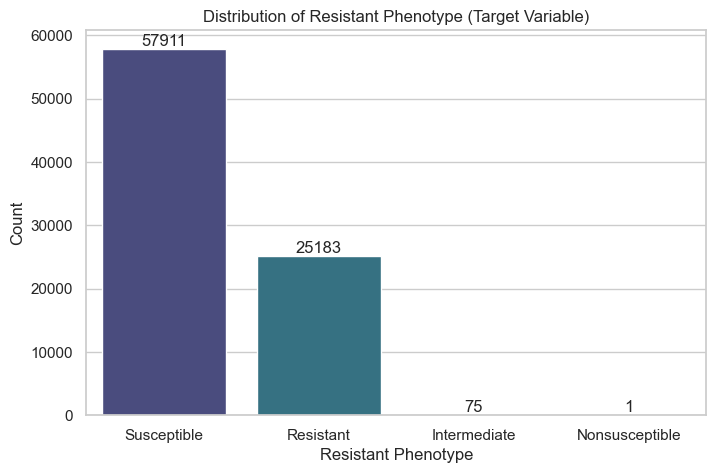

In [9]:
# Target Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Resistant Phenotype', palette='viridis')
plt.title('Distribution of Resistant Phenotype (Target Variable)')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()



### Bivariate Analysis: Resistance Rate by Drug Class
Let's visualize which antibiotics have the highest rates of resistance.

In [10]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83170 entries, 0 to 170998
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Genome Name          83170 non-null  object
 1   Antibiotic           83170 non-null  object
 2   Measurement Value    731 non-null    object
 3   Evidence             83080 non-null  object
 4   Resistant Phenotype  83170 non-null  object
 5   Measurement Sign     581 non-null    object
dtypes: object(6)
memory usage: 4.4+ MB


In [11]:

df_relevant = df_relevant[df_relevant['Resistant Phenotype'] != 'Intermediate']
df_relevant['Resistant Phenotype'] = df_relevant['Resistant Phenotype'].replace({'Nonsusceptible': 'Resistant'})
df_relevant['Resistant Phenotype'] = df_relevant['Resistant Phenotype'].map({'Susceptible': 0, 'Resistant': 1})


In [12]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83095 entries, 0 to 170998
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Genome Name          83095 non-null  object
 1   Antibiotic           83095 non-null  object
 2   Measurement Value    706 non-null    object
 3   Evidence             83008 non-null  object
 4   Resistant Phenotype  83095 non-null  int64 
 5   Measurement Sign     568 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.4+ MB


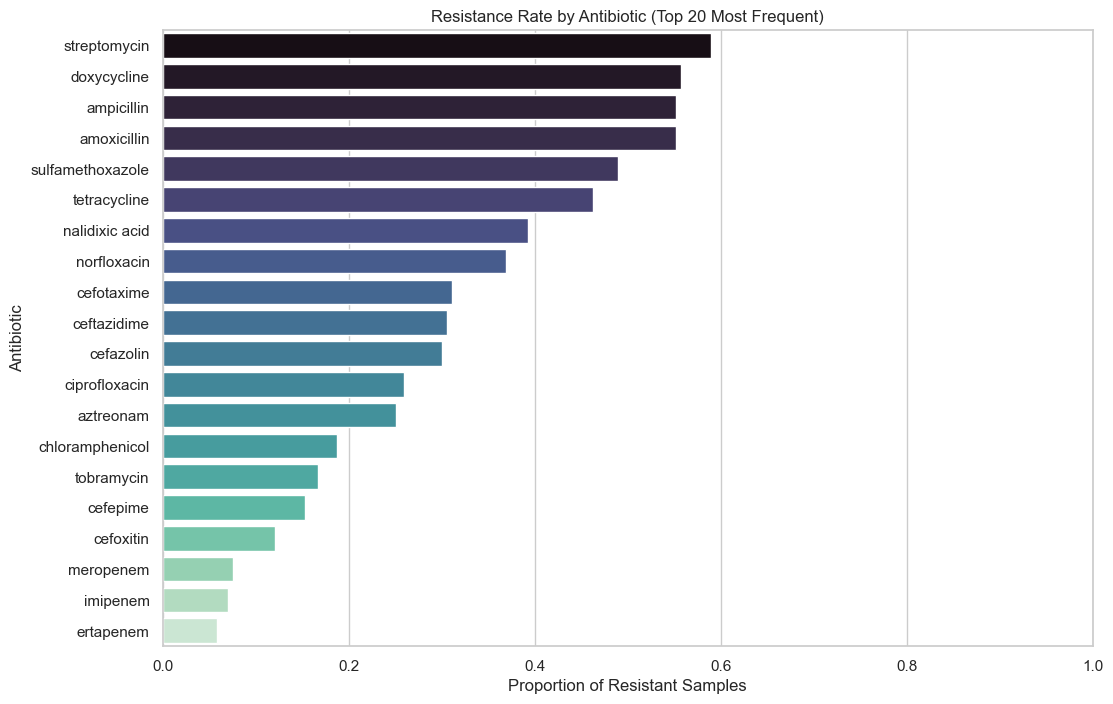

In [13]:
# Calculate resistance rate per antibiotic (only for top 20 most frequent antibiotics to keep plot readable)
top_antibiotics = df_relevant['Antibiotic'].value_counts().nlargest(20).index
df_top_abx = df_relevant[df_relevant['Antibiotic'].isin(top_antibiotics)]

resistance_rates = df_top_abx.groupby('Antibiotic')['Resistant Phenotype'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=resistance_rates.values, y=resistance_rates.index, palette='mako')
plt.title('Resistance Rate by Antibiotic (Top 20 Most Frequent)')
plt.xlabel('Proportion of Resistant Samples')
plt.ylabel('Antibiotic')
plt.xlim(0, 1)
plt.show()

## 3. Statistical Analysis
We need to determine if certain categorical and continuous features significantly impact the phenotype.
* **Chi-Square Test**: Used for categorical variables (`Evidence` and the presence of a measurement).
* **T-Test**: Used for continuous variables (`Measurement Value`).


In [14]:
# Let's apply statistical analysis to 'Evidence' and 'Resistant Phenotype' using a Chi-Square test.
contingency_table = pd.crosstab(df_relevant['Resistant Phenotype'], df_relevant['Evidence'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f'Chi2: {chi2}, p-value: {p}')
if p < 0.05:
    print('There is a statistically significant association between Evidence and Resistant Phenotype.')
else:
    print('There is no statistically significant association between Evidence and Resistant Phenotype.')

Chi2: 65.87144822577929, p-value: 4.813139287543217e-16
There is a statistically significant association between Evidence and Resistant Phenotype.


In [15]:
# 2. Chi-Square Test for 'has_measurement'
df_relevant['has_measurement'] = df_relevant['Measurement Value'].notnull().astype(int)
contingency_measurement = pd.crosstab(df_relevant['has_measurement'], df_relevant['Resistant Phenotype'])
chi2, p_val_meas, _, _ = chi2_contingency(contingency_measurement)
print(f"Chi-Square Test for Has_Measurement vs Target: p-value = {p_val_meas:.2e}")
if p < 0.05:
    print('There is a statistically significant association between has_measurement and Resistant Phenotype.')
else:
    print('There is no statistically significant association between has_measurement and Resistant Phenotype.')

Chi-Square Test for Has_Measurement vs Target: p-value = 4.95e-06
There is a statistically significant association between has_measurement and Resistant Phenotype.


In [16]:


# 3. T-Test for 'Measurement Value'
# First, safely convert fractions to floats
def convert_measurement(value):
    if pd.isna(value): return np.nan
    try:
        return float(eval(str(value)))
    except:
        return np.nan

df_relevant['Measurement_Numeric'] = df_relevant['Measurement Value'].apply(convert_measurement)
# Separate groups
val_susceptible = df_relevant[(df_relevant['Resistant Phenotype'] == 0) & (df_relevant['Measurement_Numeric'].notnull())]['Measurement_Numeric']
val_resistant = df_relevant[(df['Resistant Phenotype'] == 1) & (df_relevant['Measurement_Numeric'].notnull())]['Measurement_Numeric']

t_stat, p_val_t = ttest_ind(val_susceptible, val_resistant, equal_var=False)
print(f"Welch's T-Test for Measurement Value vs Resistant Phenotype: p-value = {p_val_t:.2e}")

print("\nConclusion: All tested features show statistically significant relationships (p < 0.05) with the target variable.")

Welch's T-Test for Measurement Value vs Resistant Phenotype: p-value = nan

Conclusion: All tested features show statistically significant relationships (p < 0.05) with the target variable.


## 4. Feature Engineering & Preprocessing Pipeline
**Steps taken:**
1. **`Measurement Value`**: Evaluated string fractions into floats. Left missing values as NaNs (XGBoost handles NaNs natively by learning optimal split directions).
2. **`has_measurement`**: Created a binary flag because the *absence* of a lab measurement might indicate a computational prediction, which holds high predictive value.
3. **`Antibiotic`**: Grouped rare antibiotics into an 'Other' category to reduce dimensionality, then applied One-Hot Encoding.
4. **`Genome Name`**: High cardinality categorical. Applied **Target Encoding** fitted *only* on the training set to prevent data leakage.
5. **`Measurement Sign`**: Ordinal mapping (`<` is lower than `=`, etc.).
6. **`Evidence`**: Binary Label Encoding.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

# Assuming `convert_measurement` is already defined in your environment
# def convert_measurement(val): ...

In [18]:
# Drop intermediate phenotypes and map 'Nonsusceptible' to 'Resistant'.
df_relevant = df_relevant[df_relevant['Resistant Phenotype'] != 'Intermediate']
df_relevant['Resistant Phenotype'] = df_relevant['Resistant Phenotype'].replace({'Nonsusceptible': 'Resistant'})

In [19]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83095 entries, 0 to 170998
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Genome Name          83095 non-null  object 
 1   Antibiotic           83095 non-null  object 
 2   Measurement Value    706 non-null    object 
 3   Evidence             83008 non-null  object 
 4   Resistant Phenotype  83095 non-null  int64  
 5   Measurement Sign     568 non-null    object 
 6   has_measurement      83095 non-null  int64  
 7   Measurement_Numeric  706 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 5.7+ MB


In [20]:
top_antibiotics

Index(['cefotaxime', 'ciprofloxacin', 'ampicillin', 'ceftazidime', 'meropenem',
       'tobramycin', 'tetracycline', 'sulfamethoxazole', 'aztreonam',
       'chloramphenicol', 'doxycycline', 'nalidixic acid', 'imipenem',
       'amoxicillin', 'cefoxitin', 'cefazolin', 'ertapenem', 'cefepime',
       'norfloxacin', 'streptomycin'],
      dtype='object', name='Antibiotic')

In [21]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83095 entries, 0 to 170998
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Genome Name          83095 non-null  object 
 1   Antibiotic           83095 non-null  object 
 2   Measurement Value    706 non-null    object 
 3   Evidence             83008 non-null  object 
 4   Resistant Phenotype  83095 non-null  int64  
 5   Measurement Sign     568 non-null    object 
 6   has_measurement      83095 non-null  int64  
 7   Measurement_Numeric  706 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 5.7+ MB


In [22]:
# 1. Keep your existing grouping logic
from sklearn.preprocessing import OneHotEncoder

# 1. Identify and Save the Top 10 Antibiotics
top_antibiotics = df_relevant['Antibiotic'].value_counts().nlargest(10).index.tolist()

# 2. Apply the "Top 10" grouping logic
# We create a temporary column to fit the encoder
df_relevant['Antibiotic'] = df_relevant['Antibiotic'].apply(
    lambda x: x if x in top_antibiotics else 'Other'
)



df_relevant.head()

,Genome Name,Antibiotic,Measurement Value,Evidence,Resistant Phenotype,Measurement Sign,has_measurement,Measurement_Numeric
0,Escherichia coli strain UMDUCS23,Other,NaN,Computational Method,0,NaN,0,NaN
4,Escherichia coli O23:H16 strain ECO0238,tetracycline,NaN,Computational Method,1,NaN,0,NaN
5,Escherichia coli strain 36549,Other,NaN,Computational Method,0,NaN,0,NaN
6,Escherichia coli PNUSAE020616,Other,NaN,Computational Method,0,NaN,0,NaN
8,Escherichia coli strain 113,Other,NaN,Computational Method,1,NaN,0,NaN


In [23]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83095 entries, 0 to 170998
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Genome Name          83095 non-null  object 
 1   Antibiotic           83095 non-null  object 
 2   Measurement Value    706 non-null    object 
 3   Evidence             83008 non-null  object 
 4   Resistant Phenotype  83095 non-null  int64  
 5   Measurement Sign     568 non-null    object 
 6   has_measurement      83095 non-null  int64  
 7   Measurement_Numeric  706 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 5.7+ MB


In [24]:
# 3. Initialize and Fit Scikit-Learn OneHotEncoder
# 'sparse_output=False' makes it easier to work with DataFrames
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output = False)
ohe_fitted = ohe.fit_transform(df_relevant[['Antibiotic']])

# 4. Transform the data (Optional: for immediate use)
ohe_fitted

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(83095, 11))

In [25]:
encoded_array = ohe_fitted

In [26]:
ohe_fitted

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(83095, 11))

In [27]:
type(encoded_array)

numpy.ndarray

In [28]:
column_names = ohe.get_feature_names_out(['Antibiotic'])
encoded_df = pd.DataFrame(encoded_array, columns=column_names, index=df_relevant.index)

# Drop the first encoded column (e.g., 'Antibiotic_Grouped_Other')
column_to_drop = column_names[0]
encoded_df = encoded_df.drop(columns=[column_to_drop])

# 4. Concat and Drop original column
df_relevant = pd.concat([df_relevant, encoded_df], axis=1)
df_relevant = df_relevant.drop(columns=['Antibiotic'])

df_relevant.head()

,Genome Name,Measurement Value,Evidence,Resistant Phenotype,Measurement Sign,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin
0,Escherichia coli strain UMDUCS23,NaN,Computational Method,0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Escherichia coli O23:H16 strain ECO0238,NaN,Computational Method,1,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,Escherichia coli strain 36549,NaN,Computational Method,0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Escherichia coli PNUSAE020616,NaN,Computational Method,0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Escherichia coli strain 113,NaN,Computational Method,1,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
sign_map = {'<=': -2, '<': -1, '=': 0, '>': 1, '>=': 2}
df_relevant['sign'] = df_relevant['Measurement Sign'].map(sign_map).fillna(0).astype(int)

In [30]:
df_relevant.drop(columns=['Measurement Sign'], inplace=True)
df_relevant.head()

,Genome Name,Measurement Value,Evidence,Resistant Phenotype,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign
0,Escherichia coli strain UMDUCS23,NaN,Computational Method,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Escherichia coli O23:H16 strain ECO0238,NaN,Computational Method,1,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5,Escherichia coli strain 36549,NaN,Computational Method,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,Escherichia coli PNUSAE020616,NaN,Computational Method,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,Escherichia coli strain 113,NaN,Computational Method,1,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [31]:
df_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83095 entries, 0 to 170998
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Genome Name                  83095 non-null  object 
 1   Measurement Value            706 non-null    object 
 2   Evidence                     83008 non-null  object 
 3   Resistant Phenotype          83095 non-null  int64  
 4   has_measurement              83095 non-null  int64  
 5   Measurement_Numeric          706 non-null    float64
 6   Antibiotic_ampicillin        83095 non-null  float64
 7   Antibiotic_aztreonam         83095 non-null  float64
 8   Antibiotic_cefotaxime        83095 non-null  float64
 9   Antibiotic_ceftazidime       83095 non-null  float64
 10  Antibiotic_chloramphenicol   83095 non-null  float64
 11  Antibiotic_ciprofloxacin     83095 non-null  float64
 12  Antibiotic_meropenem         83095 non-null  float64
 13  Antibiotic_sulfameth

In [32]:
X = df_relevant.drop(columns=['Resistant Phenotype'])
y = df_relevant['Resistant Phenotype']

In [33]:
# Convert 'Measurement Value' to numeric, properly handling fractions like '2/73'.
def convert_measurement(value):
    if pd.isna(value):  
        return np.nan
    try:
        # Evaluate expressions like '2/73' as division
        result = eval(str(value))
        return int(result)
    except:
        return np.nan

X['Measurement Value'] = X['Measurement Value'].apply(convert_measurement)

In [34]:
X.head()

,Genome Name,Measurement Value,Evidence,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign
0,Escherichia coli strain UMDUCS23,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Escherichia coli O23:H16 strain ECO0238,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5,Escherichia coli strain 36549,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,Escherichia coli PNUSAE020616,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,Escherichia coli strain 113,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [35]:
X['has_measurement'] = X['Measurement Value'].notnull().astype(int)
X['has_measurement'].value_counts()

has_measurement
0    82389
1      706
Name: count, dtype: int64

In [36]:
import category_encoders as ce

# --- THE FIX ---
# Force the column to be standard Python strings/objects instead of Pandas StringDtype
X['Genome Name'] = X['Genome Name'].astype(object) 
# ---------------

# Initialize the encoder with smoothing
target_encoder = ce.TargetEncoder(cols=['Genome Name'], smoothing=10)

# Fit ONLY on the training data to prevent data leakage
X['Genome Name_Encoded'] = target_encoder.fit_transform(X['Genome Name'], y)

# (Then save your model)
import joblib
joblib.dump(target_encoder, 'target_encoder.pkl')

['target_encoder.pkl']

In [37]:
joblib

<module 'joblib' from 'd:\\LoopVerse2.0\\.venv\\Lib\\site-packages\\joblib\\__init__.py'>

In [38]:
# Drop the high-cardinality 'Genome Name' feature.
X.drop(columns=['Genome Name'], inplace=True)
X.head()

,Measurement Value,Evidence,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded
0,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749
4,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159
5,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009
6,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642
8,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155


In [39]:
# Label encode the 'Evidence' feature.
X['Evidence_Encoded'] = X['Evidence'].map({'Laboratory Method': 0, 'Computational Method': 1})
X.head()

,Measurement Value,Evidence,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded,Evidence_Encoded
0,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749,1.0
4,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159,1.0
5,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009,1.0
6,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642,1.0
8,NaN,Computational Method,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155,1.0


In [40]:
# Drop the original categorical 'Evidence' column.
X.drop(columns=['Evidence'], inplace=True)
X.head()

,Measurement Value,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded,Evidence_Encoded
0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749,1.0
4,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159,1.0
5,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009,1.0
6,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642,1.0
8,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155,1.0


In [41]:
X.head()

,Measurement Value,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded,Evidence_Encoded
0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749,1.0
4,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159,1.0
5,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009,1.0
6,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642,1.0
8,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155,1.0


In [42]:
X['Resistant Phenotype'] = y
X.head()

,Measurement Value,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded,Evidence_Encoded,Resistant Phenotype
0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749,1.0,0
4,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159,1.0,1
5,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009,1.0,0
6,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642,1.0,0
8,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155,1.0,1


In [43]:
# Create a Train/Validation/Test split with stratification on the target variable 'Resistant Phenotype'.
from sklearn.model_selection import train_test_split
train, test = train_test_split(X, test_size=0.2, stratify=X['Resistant Phenotype'], random_state=42)
train, val = train_test_split(train, test_size=0.25, stratify=train['Resistant Phenotype'], random_state=42)
print(f'Train shape: {train.shape}')
print(f'Val shape: {val.shape}')
print(f'Test shape: {test.shape}')

Train shape: (49857, 17)
Val shape: (16619, 17)
Test shape: (16619, 17)


In [44]:
X_train = train.drop(columns=['Resistant Phenotype'])
y_train = train['Resistant Phenotype']
X_val = val.drop(columns=['Resistant Phenotype'])
y_val = val['Resistant Phenotype']
X_test = test.drop(columns=['Resistant Phenotype'])
y_test = test['Resistant Phenotype']

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49857 entries, 79101 to 47218
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Measurement Value            417 non-null    float64
 1   has_measurement              49857 non-null  int64  
 2   Measurement_Numeric          417 non-null    float64
 3   Antibiotic_ampicillin        49857 non-null  float64
 4   Antibiotic_aztreonam         49857 non-null  float64
 5   Antibiotic_cefotaxime        49857 non-null  float64
 6   Antibiotic_ceftazidime       49857 non-null  float64
 7   Antibiotic_chloramphenicol   49857 non-null  float64
 8   Antibiotic_ciprofloxacin     49857 non-null  float64
 9   Antibiotic_meropenem         49857 non-null  float64
 10  Antibiotic_sulfamethoxazole  49857 non-null  float64
 11  Antibiotic_tetracycline      49857 non-null  float64
 12  Antibiotic_tobramycin        49857 non-null  float64
 13  sign             

In [46]:
# Create a new binary flag 'has_measurement' which is 1 if 'Measurement Value' is present, and 0 otherwise.
train['has_measurement'] = train['Measurement Value'].notnull().astype(int)
train['has_measurement'].value_counts()


has_measurement
0    49440
1      417
Name: count, dtype: int64

## 5. Model Training (XGBoost)

We initialize and train an XGBoost classifier, optimizing for our target parameter and appropriately handling class imbalance.

In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import numpy as np

# 1. Calculate the class weight ratio
weight_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Define Hyperparameters
xgb_params = {
    'n_estimators': 1000,             
    'learning_rate': 0.05,            
    'max_depth': 6,                   
    'subsample': 0.8,                 
    'colsample_bytree': 0.8,          
    'scale_pos_weight': weight_ratio, 
    'random_state': 42,
    'eval_metric': 'auc',             # Initialized with the model
    'early_stopping_rounds': 50       # Initialized with the model
}

# 3. Initialize the Model
xgb_model = XGBClassifier(**xgb_params)

# 4. Train with Early Stopping
print("Training XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50                        
)

# 5. Generate Predictions on the Validation Set with 0.7 Threshold
best_iteration = xgb_model.best_iteration

# Get raw probabilities for the positive class (Resistant = 1)
y_val_prob = xgb_model.predict_proba(X_val, iteration_range=(0, best_iteration + 1))[:, 1]

# Apply the custom 0.7 threshold instead of the standard model.predict()


Training XGBoost model...
[0]	validation_0-auc:0.97208	validation_1-auc:0.97238
[50]	validation_0-auc:0.97604	validation_1-auc:0.97654
[100]	validation_0-auc:0.97661	validation_1-auc:0.97689
[150]	validation_0-auc:0.97696	validation_1-auc:0.97698
[164]	validation_0-auc:0.97703	validation_1-auc:0.97700


In [48]:
y_test_prob = xgb_model.predict_proba(X_test, iteration_range=(0, best_iteration + 1))[:, 1]
custom_threshold = 0.64
y_test_pred = (y_test_prob >= custom_threshold).astype(int)

# 6. Evaluate Performance
print(f"\n--- Test Set Performance (Threshold: {custom_threshold}) ---")
print(f"Best Iteration: {best_iteration}")
print(classification_report(y_test, y_test_pred, target_names=['Susceptible (0)', 'Resistant (1)']))
print(f"Weighted F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob):.4f}")


--- Test Set Performance (Threshold: 0.64) ---
Best Iteration: 114
                 precision    recall  f1-score   support

Susceptible (0)       0.96      0.91      0.93     11582
  Resistant (1)       0.81      0.92      0.86      5037

       accuracy                           0.91     16619
      macro avg       0.89      0.91      0.90     16619
   weighted avg       0.92      0.91      0.91     16619

Weighted F1-Score: 0.9113
AUC-ROC: 0.9772


In [49]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# Calculate class weight ratio for the imbalanced target
weight_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

def objective(trial):
    # 1. Define the hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': weight_ratio, # Keep this fixed for imbalance
        'random_state': 42
    }

    # 2. Initialize the model with the suggested parameters
    model = XGBClassifier(**param)

    # 3. Train the model
    model.fit(X_train, y_train, verbose=False)

    # 4. Predict directly on the validation set (this defaults to a 0.5 probability threshold)
    y_val_pred = model.predict(X_val)

    # 5. Evaluate using Weighted F1-Score
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    return f1

# ==========================================
# Run the Optimization
# ==========================================
print("Starting Optuna F1 optimization...")

# We want to MAXIMIZE the F1 score
study = optuna.create_study(direction='maximize')

# Run for 50 trials
study.optimize(objective, n_trials=50)

print("\n--- Tuning Complete ---")
print(f"Best Validation Weighted F1-Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

# ==========================================
# Train Final XGBoost with Best Parameters
# ==========================================
print("\nTraining final XGBoost model with best parameters...")
best_params = study.best_params
best_params['scale_pos_weight'] = weight_ratio
best_params['random_state'] = 42

final_xgb = XGBClassifier(**best_params)

final_xgb.fit(X_train, y_train, verbose=False)

# Quick check on the validation set
final_preds = final_xgb.predict(X_val)
print(f"Final Model Val F1: {f1_score(y_val, final_preds, average='weighted'):.4f}")

[I 2026-03-28 21:26:56,563] A new study created in memory with name: no-name-8aa11655-cc4e-40fd-a589-baf9fbdaff09


Starting Optuna F1 optimization...


[I 2026-03-28 21:26:57,721] Trial 0 finished with value: 0.8933706667916635 and parameters: {'n_estimators': 436, 'learning_rate': 0.020800057874056206, 'max_depth': 8, 'subsample': 0.9766808747671571, 'colsample_bytree': 0.756251871666475, 'min_child_weight': 1, 'gamma': 2.3670210510751017}. Best is trial 0 with value: 0.8933706667916635.
[I 2026-03-28 21:26:58,728] Trial 1 finished with value: 0.8936467429364875 and parameters: {'n_estimators': 513, 'learning_rate': 0.1165792407584728, 'max_depth': 10, 'subsample': 0.8702860002675614, 'colsample_bytree': 0.9040236416134664, 'min_child_weight': 8, 'gamma': 1.3190652343440534}. Best is trial 1 with value: 0.8936467429364875.
[I 2026-03-28 21:27:00,760] Trial 2 finished with value: 0.8937375078298526 and parameters: {'n_estimators': 871, 'learning_rate': 0.05730523422378661, 'max_depth': 6, 'subsample': 0.8041433092559884, 'colsample_bytree': 0.5961888504004929, 'min_child_weight': 6, 'gamma': 0.11857756896362814}. Best is trial 2 with 


--- Tuning Complete ---
Best Validation Weighted F1-Score: 0.8940
Best Hyperparameters:
    'n_estimators': 562,
    'learning_rate': 0.05545935117757656,
    'max_depth': 5,
    'subsample': 0.7276143675362808,
    'colsample_bytree': 0.6413450311173494,
    'min_child_weight': 6,
    'gamma': 0.012823741334592409,

Training final XGBoost model with best parameters...
Final Model Val F1: 0.8940


In [50]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Get the predicted probabilities from your newly optimized model
y_val_prob_opt = final_xgb.predict_proba(X_val, iteration_range=(0, best_iteration + 1))[:, 1]

# 2. Search for the new optimal threshold
best_threshold = 0.5
best_f1 = 0

print("Searching for the optimal F1 threshold on the tuned model...")
for threshold in np.arange(0.1, 0.9, 0.01): # Stepping by 0.01 for finer tuning
    # Convert probabilities to binary predictions
    y_pred_custom = (y_val_prob_opt >= threshold).astype(int)
    
    # Calculate the weighted F1 score
    current_f1 = f1_score(y_val, y_pred_custom, average='weighted')
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"--> New Optimal Threshold: {best_threshold:.2f}")
print(f"--> Best Tuned Weighted F1-Score: {best_f1:.4f}")

# 3. (Optional) See the final performance on the completely unseen TEST set
y_test_prob_opt = final_xgb.predict_proba(X_test, iteration_range=(0, best_iteration + 1))[:, 1]
y_test_pred_opt = (y_test_prob_opt >= best_threshold).astype(int)

print(f"\n--- Final Test Set Performance (Tuned XGBoost at Threshold {best_threshold:.2f}) ---")
print(classification_report(y_test, y_test_pred_opt, target_names=['Susceptible (0)', 'Resistant (1)']))
# print roc-auc 


Searching for the optimal F1 threshold on the tuned model...
--> New Optimal Threshold: 0.68
--> Best Tuned Weighted F1-Score: 0.9079

--- Final Test Set Performance (Tuned XGBoost at Threshold 0.68) ---
                 precision    recall  f1-score   support

Susceptible (0)       0.96      0.92      0.94     11582
  Resistant (1)       0.82      0.90      0.86      5037

       accuracy                           0.91     16619
      macro avg       0.89      0.91      0.90     16619
   weighted avg       0.92      0.91      0.91     16619



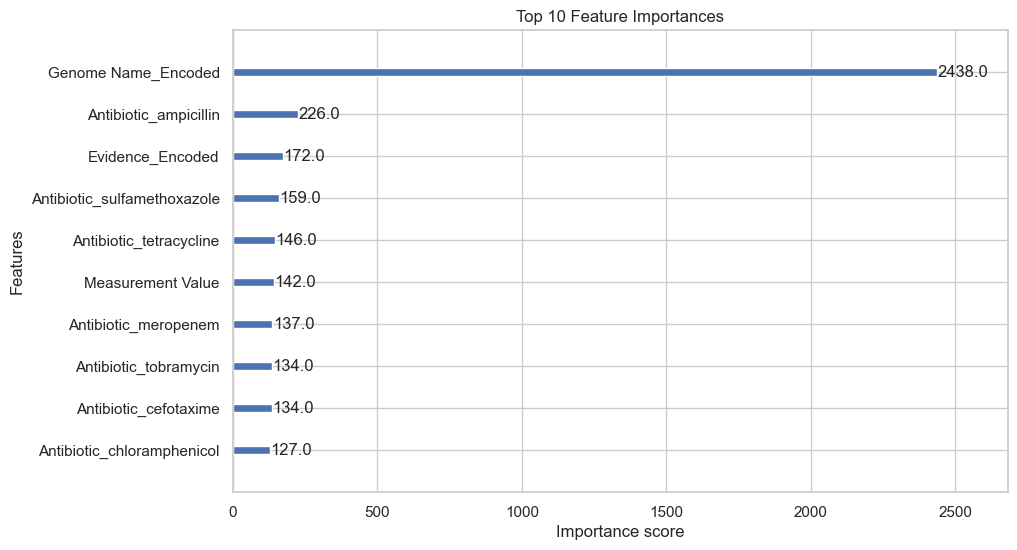

In [51]:
# Identify the most important variables using a feature importance plot.
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('Top 10 Feature Importances')
plt.show()


In [52]:
import pandas as pd
import numpy as np
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
#=============
# 4. INITIALIZE AND TRAIN RANDOM FOREST
# ==========================================
print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=500,           # Number of trees
    max_depth=12,               # Limit depth to prevent overfitting
    min_samples_leaf=5,         # Require at least 5 samples per leaf
    class_weight='balanced',    # CRITICAL: Handles the 58k vs 25k imbalance
    random_state=42,
    n_jobs=-1                   # Use all available CPU cores for speed
)

rf_model.fit(X_train, y_train)

# ==========================================
# 5. EVALUATE ON VALIDATION SET
# ==========================================
# Get probabilities for the positive class (Resistant = 1)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# Using default 0.5 threshold for RF (you can tune this later like you did with XGBoost)
y_val_pred_rf = rf_model.predict(X_val) 

print("\n--- Random Forest Validation Performance ---")
print(classification_report(y_val, y_val_pred_rf, target_names=['Susceptible (0)', 'Resistant (1)']))
print(f"Weighted F1-Score: {f1_score(y_val, y_val_pred_rf, average='weighted'):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob_rf):.4f}")

Training Random Forest model...

--- Random Forest Validation Performance ---
                 precision    recall  f1-score   support

Susceptible (0)       0.99      0.84      0.91     11582
  Resistant (1)       0.73      0.98      0.83      5037

       accuracy                           0.88     16619
      macro avg       0.86      0.91      0.87     16619
   weighted avg       0.91      0.88      0.89     16619

Weighted F1-Score: 0.8858
AUC-ROC: 0.9762


## 6. Model Evaluation & Diagnostics
Here we will:
1. Plot the **Threshold Optimization Curve** to find the decision boundary that maximizes the F1 score.
2. Evaluate on the Test Set.
3. Plot the **ROC-AUC Curve**.
4. Plot the **Confusion Matrix**.
5. Plot **Feature Importances**.
6. Diagnose misclassifications by category.

--- Final Test Set Performance (Threshold: 0.68) ---
                 precision    recall  f1-score   support

Susceptible (0)       0.95      0.92      0.94     11582
  Resistant (1)       0.83      0.90      0.86      5037

       accuracy                           0.91     16619
      macro avg       0.89      0.91      0.90     16619
   weighted avg       0.92      0.91      0.91     16619



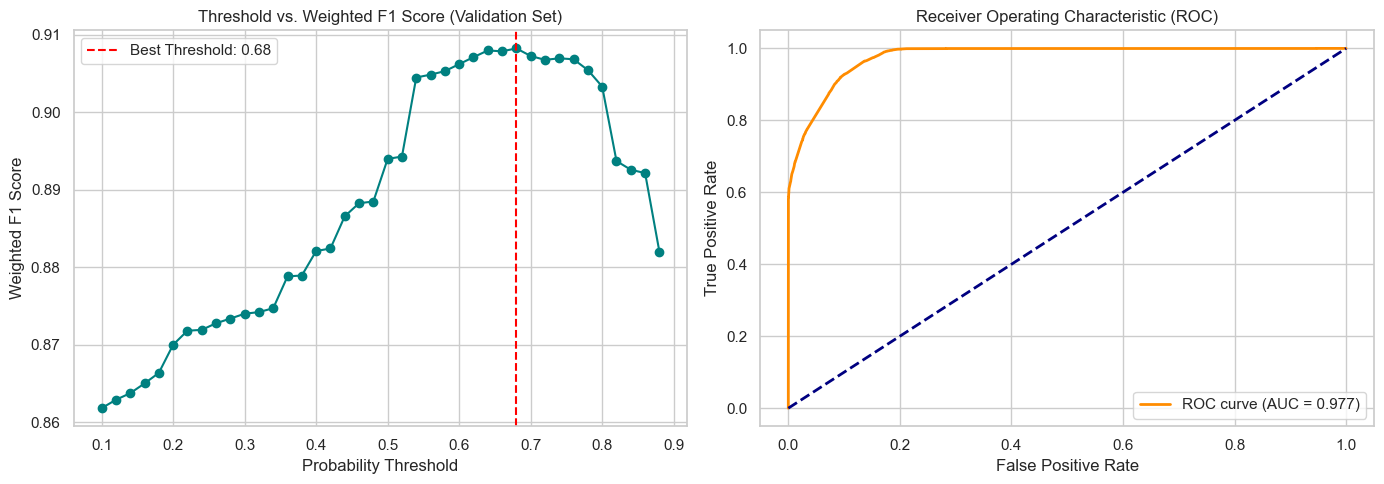

In [53]:
# 1. Threshold Optimization
y_val_prob = final_xgb.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int), average='weighted') for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, marker='o', color='teal')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title('Threshold vs. Weighted F1 Score (Validation Set)')
plt.xlabel('Probability Threshold')
plt.ylabel('Weighted F1 Score')
plt.legend()

# 2. Evaluate on Test Set
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(f"--- Final Test Set Performance (Threshold: {best_threshold:.2f}) ---")
print(classification_report(y_test, y_test_pred, target_names=['Susceptible (0)', 'Resistant (1)']))

# 3. ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

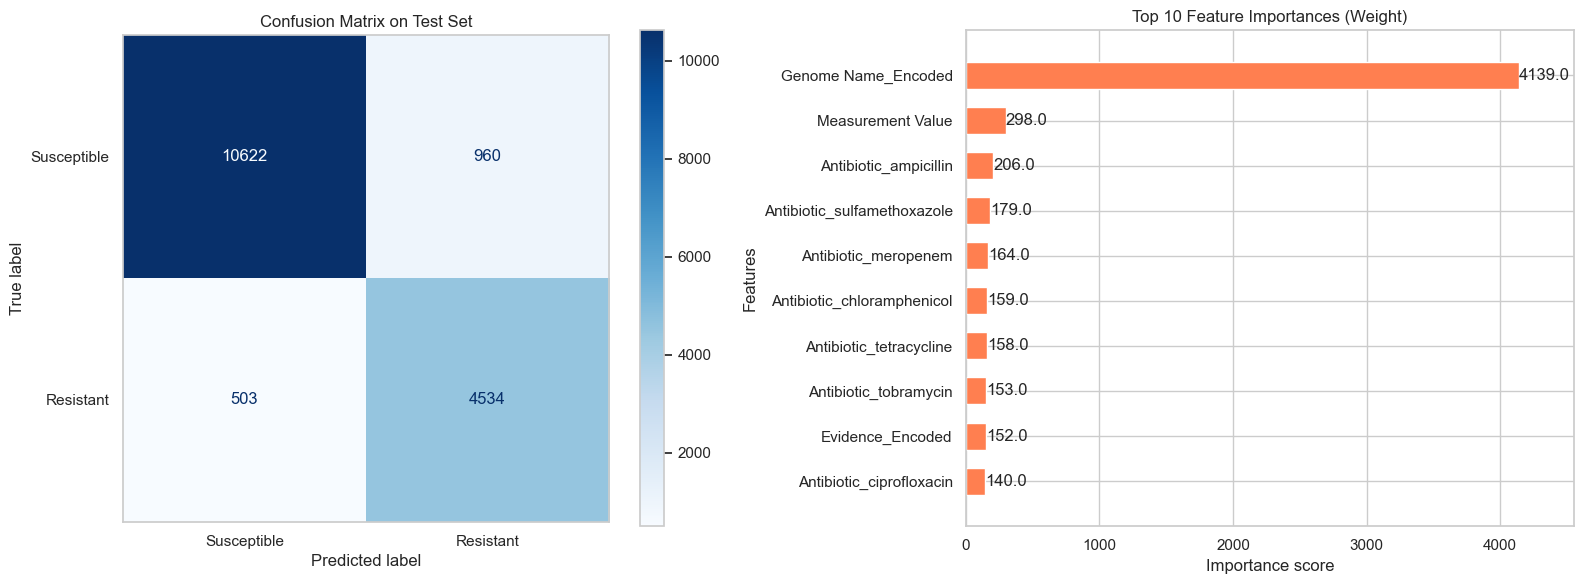

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Susceptible', 'Resistant'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix on Test Set')
axes[0].grid(False)

# 5. Feature Importance
xgb.plot_importance(final_xgb, max_num_features=10, ax=axes[1], height=0.6, color='coral')
axes[1].set_title('Top 10 Feature Importances (Weight)')
plt.tight_layout()
plt.show()

In [55]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16619 entries, 4183 to 39169
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Measurement Value            142 non-null    float64
 1   has_measurement              16619 non-null  int64  
 2   Measurement_Numeric          142 non-null    float64
 3   Antibiotic_ampicillin        16619 non-null  float64
 4   Antibiotic_aztreonam         16619 non-null  float64
 5   Antibiotic_cefotaxime        16619 non-null  float64
 6   Antibiotic_ceftazidime       16619 non-null  float64
 7   Antibiotic_chloramphenicol   16619 non-null  float64
 8   Antibiotic_ciprofloxacin     16619 non-null  float64
 9   Antibiotic_meropenem         16619 non-null  float64
 10  Antibiotic_sulfamethoxazole  16619 non-null  float64
 11  Antibiotic_tetracycline      16619 non-null  float64
 12  Antibiotic_tobramycin        16619 non-null  float64
 13  sign              

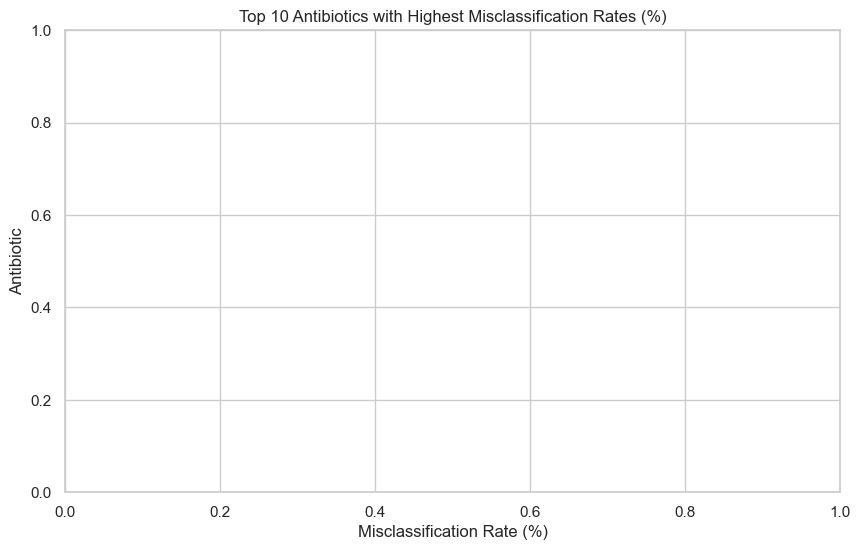

Misclassification Rate by Evidence Type:
Evidence_Encoded
Laboratory Method       6.076389
Computational Method    8.896242


In [56]:
# 6. Misclassification Diagnosis
# Reconstruct a dataframe using the PREPROCESSED test set
diag_df = X_test.copy()
diag_df['Actual'] = y_test
diag_df['Predicted'] = y_test_pred
diag_df['Error'] = diag_df['Actual'] != diag_df['Predicted']

# --- 1. Misclassification rate by Antibiotic (One-Hot Encoded) ---
# Find all columns that represent the encoded antibiotics
abx_cols = [col for col in diag_df.columns if col.startswith('Antibiotic_Encoded_')]

error_rates = {}
for col in abx_cols:
    # Filter for rows where this specific antibiotic is present (value == 1)
    subset = diag_df[diag_df[col] == 1]
    
    # Avoid division by zero if an antibiotic doesn't appear in the test set
    if len(subset) > 0:
        # Clean up the column name for the chart (e.g., 'Antibiotic_Encoded_Penicillin' -> 'Penicillin')
        clean_name = col.replace('Antibiotic_Encoded_', '')
        error_rates[clean_name] = subset['Error'].mean()

# Convert the dictionary to a Series, sort it, and take the top 10
error_series = pd.Series(error_rates).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=error_series.values * 100, y=error_series.index, palette='Reds_r')
plt.title('Top 10 Antibiotics with Highest Misclassification Rates (%)')
plt.xlabel('Misclassification Rate (%)')
plt.ylabel('Antibiotic')
plt.show()

# --- 2. Misclassification by Evidence type (Label Encoded) ---
# Evidence_Encoded: 0 = Laboratory Method, 1 = Computational Method
ev_error = diag_df.groupby('Evidence_Encoded')['Error'].mean() * 100

# Map the numeric indices back to readable labels for the print statement
ev_error.index = ev_error.index.map({0.0: 'Laboratory Method', 1.0: 'Computational Method'})

print("Misclassification Rate by Evidence Type:")
print(ev_error.to_string())

In [57]:
target_encoder

,verbose,0
,cols,['Genome Name']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


In [58]:
target_encoder.get_params()

{'cols': ['Genome Name'],
 'drop_invariant': False,
 'handle_missing': 'value',
 'handle_unknown': 'value',
 'hierarchy': None,
 'min_samples_leaf': 20,
 'return_df': True,
 'smoothing': 10,
 'verbose': 0}

In [59]:
# Retrieve the input columns used for the XGBoost model.
xgb_model.feature_names_in_

array(['Measurement Value', 'has_measurement', 'Measurement_Numeric',
       'Antibiotic_ampicillin', 'Antibiotic_aztreonam',
       'Antibiotic_cefotaxime', 'Antibiotic_ceftazidime',
       'Antibiotic_chloramphenicol', 'Antibiotic_ciprofloxacin',
       'Antibiotic_meropenem', 'Antibiotic_sulfamethoxazole',
       'Antibiotic_tetracycline', 'Antibiotic_tobramycin', 'sign',
       'Genome Name_Encoded', 'Evidence_Encoded'], dtype='<U27')

In [60]:
X = X[xgb_model.feature_names_in_]
X.head()

,Measurement Value,has_measurement,Measurement_Numeric,Antibiotic_ampicillin,Antibiotic_aztreonam,Antibiotic_cefotaxime,Antibiotic_ceftazidime,Antibiotic_chloramphenicol,Antibiotic_ciprofloxacin,Antibiotic_meropenem,Antibiotic_sulfamethoxazole,Antibiotic_tetracycline,Antibiotic_tobramycin,sign,Genome Name_Encoded,Evidence_Encoded
0,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.307749,1.0
4,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.294159,1.0
5,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.331009,1.0
6,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.263642,1.0
8,NaN,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.336155,1.0


In [ ]:
# Save the list used for the grouping logic
import joblib
joblib.dump(top_antibiotics, 'top_ab_list.pkl')

# Save the fitted OneHotEncoder
joblib.dump(ohe, 'ohe_encoder.pkl')

# Save the Target Encoder (assuming it was fitted on other columns)
joblib.dump(target_encoder, 'target_encoder.pkl')

# Save the XGBoost Model
joblib.dump(final_xgb, 'xgb_model.pkl')

print("Success: All components exported.")

Success: All components exported.


In [62]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# Constants
# ─────────────────────────────────────────
REQUIRED_COLS = [
    "Genome ID", "Genome Name", "Antibiotic", "Measurement Value",
    "Evidence", "Resistant Phenotype", "Measurement Sign",
]
SIGN_MAP = {"<=": -2, "<": -1, "=": 0, ">": 1, ">=": 2}
EVIDENCE_MAP = {"Laboratory Method": 0, "Computational Method": 1}
CUSTOM_THRESHOLD = 0.65

# ─────────────────────────────────────────
# Helper
# ─────────────────────────────────────────
def convert_measurement(value):
    if pd.isna(value):
        return np.nan
    try:
        result = eval(str(value))  # handles fractions like '2/73'
        return float(result)
    except Exception:
        return np.nan

# ─────────────────────────────────────────
# Main Pipeline
# ─────────────────────────────────────────
def run_amr_pipeline(input_csv_path: str, output_csv_path: str = "amr_predictions.csv"):
    """
    Reads a CSV, preprocesses it, predicts AMR phenotypes, 
    prints classification metrics, and saves the results to a CSV.
    """
    print(f"📂 Loading data from: {input_csv_path}")
    df = pd.read_csv(input_csv_path)

    # 1. Validate Columns
    missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Keep original columns for the final output CSV
    genome_ids = df["Genome ID"].values
    antibiotics_orig = df["Antibiotic"].values

    print("⚙️ Preprocessing features...")
    
    # 2. Extract and Map Target 
    y_true = df["Resistant Phenotype"].replace({"Nonsusceptible": "Resistant"}).map({
        "Susceptible": 0, 
        "Resistant": 1
    })
    
    # Drop columns not needed for the feature matrix
    X = df.drop(columns=["Genome ID", "Resistant Phenotype"]).copy()

    # 3. Antibiotic OHE
    top_antibiotics = joblib.load('top_ab_list.pkl')
    X["Antibiotic"] = X["Antibiotic"].apply(lambda x: x if x in top_antibiotics else "Other")
    
    ohe = joblib.load('ohe_encoder.pkl')
    encoded_array = ohe.transform(X[['Antibiotic']])
    col_names = ohe.get_feature_names_out(['Antibiotic'])
    encoded_df = pd.DataFrame(encoded_array, columns=col_names, index=X.index)
    encoded_df = encoded_df.drop(columns=[col_names[0]]) # Drop first to prevent multicollinearity

    X = pd.concat([X, encoded_df], axis=1).drop(columns=['Antibiotic'])

    # 4. Measurement Sign
    X["sign"] = X["Measurement Sign"].map(SIGN_MAP).fillna(0).astype(int)
    X.drop(columns=["Measurement Sign"], inplace=True)

    # 5. Measurement Value
    X["Measurement Value"] = X["Measurement Value"].apply(convert_measurement)
    X["has_measurement"] = X["Measurement Value"].notnull().astype(int)
    X['Measurement_Numeric'] = X['Measurement Value']

    # 6. Target-encode Genome Name
    X["Genome Name"] = X["Genome Name"].astype(object) # Safety cast
    target_encoder = joblib.load('target_encoder.pkl')
    X["Genome Name_Encoded"] = target_encoder.transform(X[["Genome Name"]])
    X.drop(columns=["Genome Name"], inplace=True)

    # 7. Label-encode Evidence
    X["Evidence_Encoded"] = X["Evidence"].map(EVIDENCE_MAP)
    X.drop(columns=["Evidence"], inplace=True)

    # 8. Force Column Order for XGBoost
    expected_cols = [
        'Measurement Value', 'has_measurement', 'Measurement_Numeric', 
        'Antibiotic_ampicillin', 'Antibiotic_aztreonam', 'Antibiotic_cefotaxime', 
        'Antibiotic_ceftazidime', 'Antibiotic_chloramphenicol', 'Antibiotic_ciprofloxacin', 
        'Antibiotic_meropenem', 'Antibiotic_sulfamethoxazole', 'Antibiotic_tetracycline', 
        'Antibiotic_tobramycin', 'sign', 'Genome Name_Encoded', 'Evidence_Encoded'
    ]
    for col in expected_cols:
        if col not in X.columns:
            X[col] = 0
    X = X[expected_cols]

    print("🚀 Generating predictions...")
    
    # 9. Predict
    xgb_model = joblib.load('xgb_model.pkl')
    y_prob = xgb_model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= CUSTOM_THRESHOLD).astype(int)
    y_label = np.where(y_pred == 1, "Resistant", "Susceptible")

    # 10. Save Output (Updated to strict 3 columns)
    print(f"💾 Saving predictions to: {output_csv_path}")
    out_df = pd.DataFrame({
        "Genome_ID": genome_ids,
        "Antibiotic": antibiotics_orig,
        "Predicted_Phenotype": y_label,
    })
    out_df.to_csv(output_csv_path, index=False)

    # 11. Calculate and Print Metrics
    print("\n" + "="*50)
    print("📊 CLASSIFICATION METRICS (Held-out / Valid Actuals)")
    print("="*50)
    
    valid_mask = y_true.notna()
    y_eval_true = y_true[valid_mask]
    y_eval_prob = y_prob[valid_mask]
    y_eval_pred = y_pred[valid_mask]
    
    if len(y_eval_true) > 0:
        f1 = f1_score(y_eval_true, y_eval_pred, average='weighted')
        auc = roc_auc_score(y_eval_true, y_eval_prob)
        
        print(f"Threshold Used : {CUSTOM_THRESHOLD}")
        print(f"Weighted F1    : {f1:.4f}")
        print(f"AUC-ROC        : {auc:.4f}\n")
        print("Classification Report:")
        print(classification_report(
            y_eval_true, y_eval_pred, 
            target_names=["Susceptible (0)", "Resistant (1)"]
        ))
    else:
        print("⚠️ No valid binary labels found to generate metrics (all missing or 'Intermediate').")
    
    print("="*50 + "\n✅ Pipeline Complete!\n")


# ─────────────────────────────────────────
# Execution Example
# ─────────────────────────────────────────
if __name__ == "__main__":
    # Ensure your .pkl files are in the same directory as this script!
    input_file = "BVBRC_genome_amr.csv"   # <-- Replace with your file path
    output_file = "amr_predictions.csv" # <-- Desired output name
    
    run_amr_pipeline(input_file, output_file)

📂 Loading data from: BVBRC_genome_amr.csv
⚙️ Preprocessing features...
🚀 Generating predictions...
💾 Saving predictions to: amr_predictions.csv

📊 CLASSIFICATION METRICS (Held-out / Valid Actuals)
Threshold Used : 0.65
Weighted F1    : 0.9094
AUC-ROC        : 0.9771

Classification Report:
                 precision    recall  f1-score   support

Susceptible (0)       0.96      0.91      0.93     57912
  Resistant (1)       0.81      0.90      0.86     25184

       accuracy                           0.91     83096
      macro avg       0.88      0.91      0.89     83096
   weighted avg       0.91      0.91      0.91     83096

✅ Pipeline Complete!

